# 05 · Uncertainty: Predicting a Range

A single number, like "next hour: 12 kWh", hides how **sure** the model is. On a clear day it's
almost certain. On a cloudy day it could easily be off by 8 kWh.

Grid operators need to know this, to decide how much backup power to keep ready. So in this notebook
the model predicts a **range**:

> "12 kWh, and 90% sure it will be between 8 and 15 kWh."

**Three methods:**

| Method | Idea |
|---|---|
| **Fixed range** (simple reference) | smart persistence ± the typical size of its past errors. Same width every hour. |
| **Quantile regression** | train Gradient Boosting to predict a *low* and a *high* value directly |
| **Conformalized quantile regression (CQR)** | quantile regression, then *calibrated* so the promised coverage really holds |

**Data use:** train on 2017 · calibrate on 2018 · test on 2019.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.data import load_hourly, split, LOCAL_TZ
from src.baselines import make_baselines, climatology
from src.features import FEATURE_SETS
from src.models import fit_predict
from src.uncertainty import coverage, mean_width, interval_score, conformal_margin

FIGURES, RESULTS = ROOT / "results" / "figures", ROOT / "results"

y = load_hourly()
baselines, daytime = make_baselines(y)
X = pd.read_parquet(ROOT / "data" / "processed" / "features_hourly.parquet")
X.index = X.index.tz_convert(LOCAL_TZ).rename("time")
REALISTIC = FEATURE_SETS["time_sun"] + FEATURE_SETS["past_pv"] + FEATURE_SETS["obs_weather"]

LEVELS = {"80%": 0.2, "90%": 0.1}      # range level -> alpha (the share we allow to fall outside)

## How we score a range

| Measure | Question it answers | Good value |
|---|---|---|
| **Coverage** | How often is the true value inside the range? | Close to the promise (80% or 90%) |
| **Width** | How wide is the range on average? | Narrow, but only if coverage holds |
| **Interval score** (Winkler) | Width + a penalty for every miss | Lower is better |

**Why not just width?** A range of 0 to 30 kWh always "covers", but it's useless.
**Why not just coverage?** A tiny range that misses half the time is dangerous.
The interval score balances both in one number.

## Method 1 · Fixed range around smart persistence

Look at smart persistence's errors in 2018 (calibration year). The 5th and 95th percentiles of those
errors become a fixed "±" band. Simple, and a fair reference to beat.

In [2]:
sp = baselines["Smart persistence"]
errors = (split(y, "val") - split(sp, "val"))[split(daytime, "val")].dropna()

ranges = {}
for level, alpha in LEVELS.items():
    lo = (sp + errors.quantile(alpha / 2)).clip(lower=0)
    hi = sp + errors.quantile(1 - alpha / 2)
    ranges[("Fixed range", level)] = (lo, hi)
    print(f"{level}: smart persistence {errors.quantile(alpha / 2):+.2f} / {errors.quantile(1 - alpha / 2):+.2f} kWh")

80%: smart persistence -1.48 / +2.52 kWh
90%: smart persistence -2.69 / +3.92 kWh


## Method 2 · Quantile regression

Normal regression predicts the **average** outcome. **Quantile regression** predicts a chosen
**percentile** instead. For example, the 5th percentile means "95% of the time, the real value will be
higher than this".

We train one Gradient Boosting model per percentile, using `loss="quantile"`:

- 5th and 95th percentiles → a 90% range
- 10th and 90th percentiles → an 80% range
- 50th percentile (the median) → the middle forecast

In [3]:
def quantile_model(q):
    return HistGradientBoostingRegressor(loss="quantile", quantile=q, max_iter=500, learning_rate=0.03,
                                         max_leaf_nodes=15, min_samples_leaf=50, random_state=42)

Q = {}
for q in [0.05, 0.1, 0.5, 0.9, 0.95]:
    Q[q], _ = fit_predict(quantile_model(q), X, REALISTIC, ["train"])   # trained on 2017 only

for level, alpha in LEVELS.items():
    ranges[("Quantile regression", level)] = (Q[alpha / 2], Q[1 - alpha / 2])

## Method 3 · Conformalized quantile regression (CQR)

Quantile regression is often **overconfident**: its ranges come out too narrow. **Conformal prediction**
is a modern statistics method that fixes this with a simple, guaranteed recipe (Romano et al., 2019):

1. On the **calibration year (2018)**, measure how far each true value falls **outside** the predicted
   range (a negative number if it's inside).
2. Take the 90th percentile of those distances. That's the **margin**.
3. Widen every future range by that margin, on both sides.

**The guarantee:** if the future behaves like the calibration data, the range will contain the truth at
least 90% of the time, whatever model you use. That's why conformal prediction is popular in
safety-critical AI.

In [4]:
for level, alpha in LEVELS.items():
    lo, hi = Q[alpha / 2], Q[1 - alpha / 2]
    cal = pd.concat([split(y, "val"), split(lo, "val"), split(hi, "val")], axis=1)[split(daytime, "val")].dropna()
    margin = conformal_margin(cal.iloc[:, 0], cal.iloc[:, 1], cal.iloc[:, 2], level=1 - alpha)
    ranges[("CQR", level)] = ((lo - margin).clip(lower=0), hi + margin)
    print(f"{level} range: widen by {margin:.2f} kWh on each side")

80% range: widen by 0.20 kWh on each side
90% range: widen by 0.30 kWh on each side


## Results on 2019

In [5]:
rows = []
for (method, level), (lo, hi) in ranges.items():
    t = pd.concat([split(y, "test"), split(lo, "test"), split(hi, "test")], axis=1)[split(daytime, "test")].dropna()
    yt, l, h = t.iloc[:, 0], t.iloc[:, 1], t.iloc[:, 2]
    rows.append({"method": method, "range": level, "target coverage": level,
                 "coverage": coverage(yt, l, h), "width (kWh)": mean_width(l, h),
                 "interval score": interval_score(yt, l, h, LEVELS[level])})
results = pd.DataFrame(rows).set_index(["range", "method"]).sort_index()
results.round(3)

target coverage  coverage  width (kWh)  \
range method                                                       
80%   CQR                             80%     0.850        3.686   
      Fixed range                     80%     0.805        3.926   
      Quantile regression             80%     0.752        3.287   
90%   CQR                             90%     0.926        4.926   
      Fixed range                     90%     0.902        6.364   
      Quantile regression             90%     0.854        4.334   

                           interval score  
range method                               
80%   CQR                           4.929  
      Fixed range                   7.853  
      Quantile regression           4.924  
90%   CQR                           6.282  
      Fixed range                  10.644  
      Quantile regression           6.310

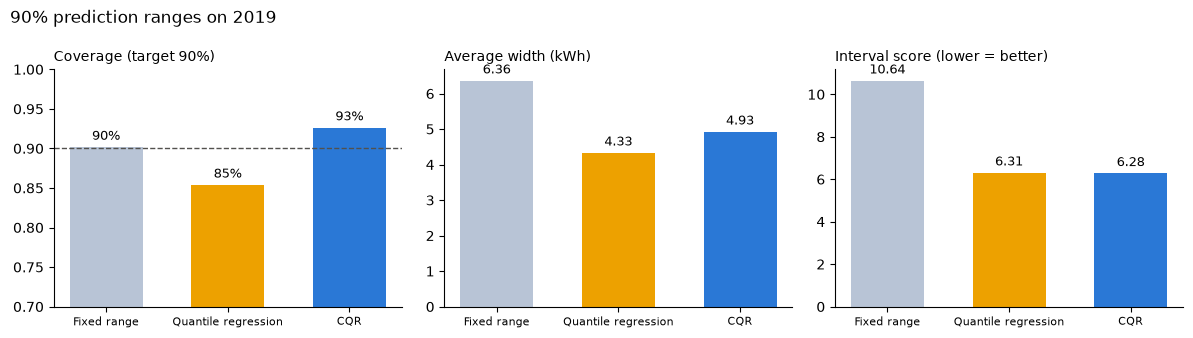

In [6]:
methods = ["Fixed range", "Quantile regression", "CQR"]
colors = {"Fixed range": "#b8c4d6", "Quantile regression": "#eda100", "CQR": "#2a78d6"}
r90 = results.loc["90%"].reindex(methods)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, col, title in zip(axes, ["coverage", "width (kWh)", "interval score"],
                          ["Coverage (target 90%)", "Average width (kWh)", "Interval score (lower = better)"]):
    bars = ax.bar(methods, r90[col], color=[colors[m] for m in methods], width=0.6)
    ax.bar_label(bars, fmt="%.0f%%" if col == "coverage" else "%.2f", padding=3, fontsize=9,
                 labels=[f"{v:.0%}" for v in r90[col]] if col == "coverage" else None)
    if col == "coverage":
        ax.axhline(0.9, color="#52514e", linestyle="--", linewidth=1)
        ax.set_ylim(0.7, 1.0)
    ax.set_title(title, loc="left", fontsize=10)
    ax.tick_params(axis="x", labelsize=8)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
fig.suptitle("90% prediction ranges on 2019", x=0.01, ha="left", fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES / "05_interval_comparison.png", dpi=130)
plt.show()

## Does the range adapt to the weather?

A good range should be **wider on cloudy days** (hard to predict) and **narrower on clear days**.
We sort the 2019 days into thirds by how sunny they were compared with a typical day, then check each
third separately.

In [7]:
clim = climatology(y)
test = pd.concat({"y": y, "clim": clim}, axis=1)
test = split(test, "test")[split(daytime, "test")]
daily_ratio = test["y"].groupby(test.index.date).sum() / test["clim"].groupby(test.index.date).sum()
day_type = pd.qcut(daily_ratio, 3, labels=["Cloudiest third", "Middle", "Sunniest third"])

rows = []
for method in ["Fixed range", "CQR"]:
    lo, hi = ranges[(method, "90%")]
    t = pd.concat({"y": y, "lo": lo, "hi": hi}, axis=1)
    t = split(t, "test")[split(daytime, "test")].dropna()
    t["day type"] = day_type.reindex(t.index.date).to_numpy()
    for dt, g in t.groupby("day type", observed=True):
        rows.append({"method": method, "day type": dt, "coverage": coverage(g.y, g.lo, g.hi), "width (kWh)": mean_width(g.lo, g.hi)})
by_day = pd.DataFrame(rows)
by_day.pivot(index="day type", columns="method").round(3)

coverage             width (kWh)            
method               CQR Fixed range         CQR Fixed range
day type                                                    
Cloudiest third    0.895       0.825       6.817       6.242
Middle             0.944       0.952       3.749       6.430
Sunniest third     0.938       0.925       4.305       6.415

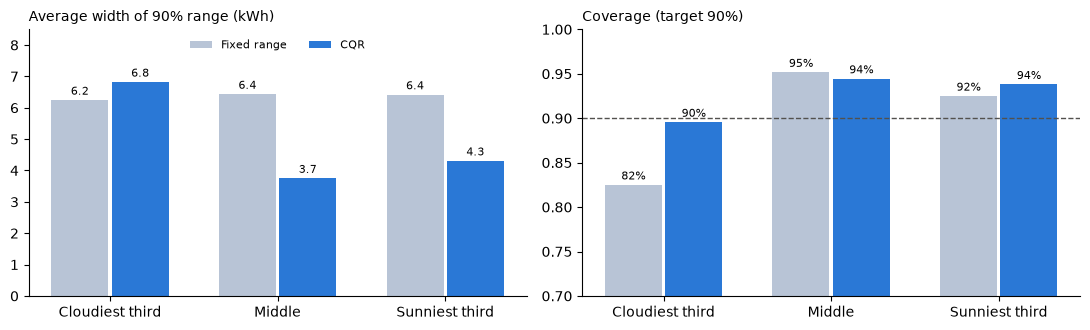

In [8]:
types = ["Cloudiest third", "Middle", "Sunniest third"]
x = np.arange(len(types))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, col, title in zip(axes, ["width (kWh)", "coverage"], ["Average width of 90% range (kWh)", "Coverage (target 90%)"]):
    for i, method in enumerate(["Fixed range", "CQR"]):
        vals = by_day[by_day.method == method].set_index("day type").reindex(types)[col]
        bars = ax.bar(x + (i - 0.5) * 0.36, vals, width=0.34, color=colors[method], label=method)
        ax.bar_label(bars, labels=[f"{v:.0%}" if col == "coverage" else f"{v:.1f}" for v in vals], padding=2, fontsize=8)
    if col == "coverage":
        ax.axhline(0.9, color="#52514e", linestyle="--", linewidth=1)
        ax.set_ylim(0.7, 1.0)
    ax.set_xticks(x, types)
    ax.set_title(title, loc="left", fontsize=10)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
axes[0].set_ylim(0, 8.5)
axes[0].legend(frameon=False, fontsize=8, ncol=2, loc="upper center")
fig.tight_layout()
fig.savefig(FIGURES / "05_adaptivity_by_day_type.png", dpi=130)
plt.show()

## See it: one week with ranges

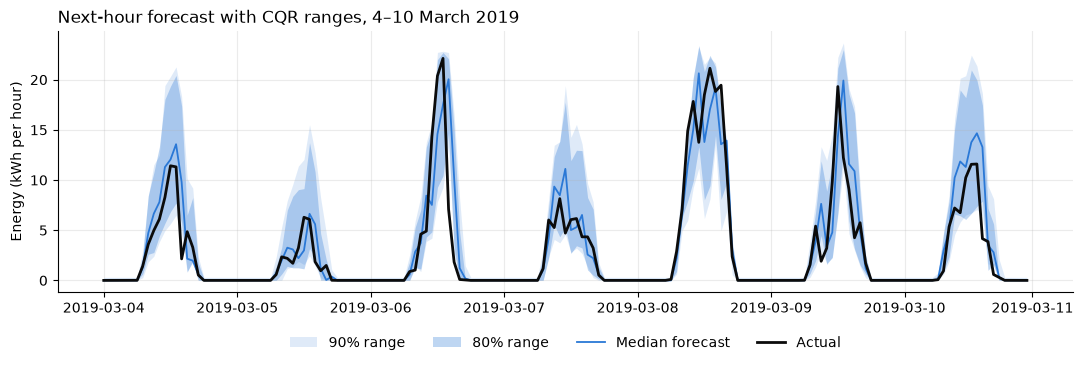

In [9]:
week = slice("2019-03-04", "2019-03-10")
lo80, hi80 = ranges[("CQR", "80%")]
lo90, hi90 = ranges[("CQR", "90%")]

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.fill_between(lo90.loc[week].index, lo90.loc[week], hi90.loc[week], color="#2a78d6", alpha=0.15, linewidth=0, label="90% range")
ax.fill_between(lo80.loc[week].index, lo80.loc[week], hi80.loc[week], color="#2a78d6", alpha=0.30, linewidth=0, label="80% range")
ax.plot(Q[0.5].loc[week].index, Q[0.5].loc[week], color="#2a78d6", linewidth=1.3, label="Median forecast")
ax.plot(y.loc[week].index, y.loc[week], color="#0b0b0b", linewidth=2, label="Actual")
ax.set_ylabel("Energy (kWh per hour)")
ax.set_title("Next-hour forecast with CQR ranges, 4–10 March 2019", loc="left")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES / "05_week_with_ranges.png", dpi=130)
plt.show()

In [10]:
results.to_csv(RESULTS / "metrics_uncertainty.csv")
by_day.to_csv(RESULTS / "uncertainty_by_day_type.csv", index=False)

## What we learned

- **Quantile regression alone is overconfident.** Its "90%" range contains the truth only about 86% of
  the time on 2019 (and about 81% on 2018).
- **CQR fixes this.** After calibration, the 90% range covers about 93% of 2019 hours. That's slightly
  more than promised, because 2018 (the calibration year) was harder to predict than 2019.
- **CQR is much sharper than the fixed range**: about 5.0 vs 6.4 kWh wide at 90%, with a much better
  interval score (about 6.3 vs 10.6).
- **CQR vs quantile regression alone:** their interval scores are almost equal (6.29 vs 6.28), but only
  CQR keeps its coverage promise. A forecast that says "90%" and delivers 86% can't be trusted for
  planning, so calibration is worth the slightly wider range.
- **CQR adapts to the weather.** It widens on cloudy days and narrows on sunny ones, and it **keeps its
  promise on cloudy days** (about 90%). The fixed range drops to about 83% on cloudy days, exactly when
  reliability matters most.

**Limitation (honest):** conformal guarantees assume the future looks like the calibration year.
If the weather pattern or the panels change (dirt, damage, new panels), the ranges need recalibrating.

**Next: Level 4, sky images.** The largest errors happen on cloudy days, and a camera looking at the sky
can see the clouds coming.